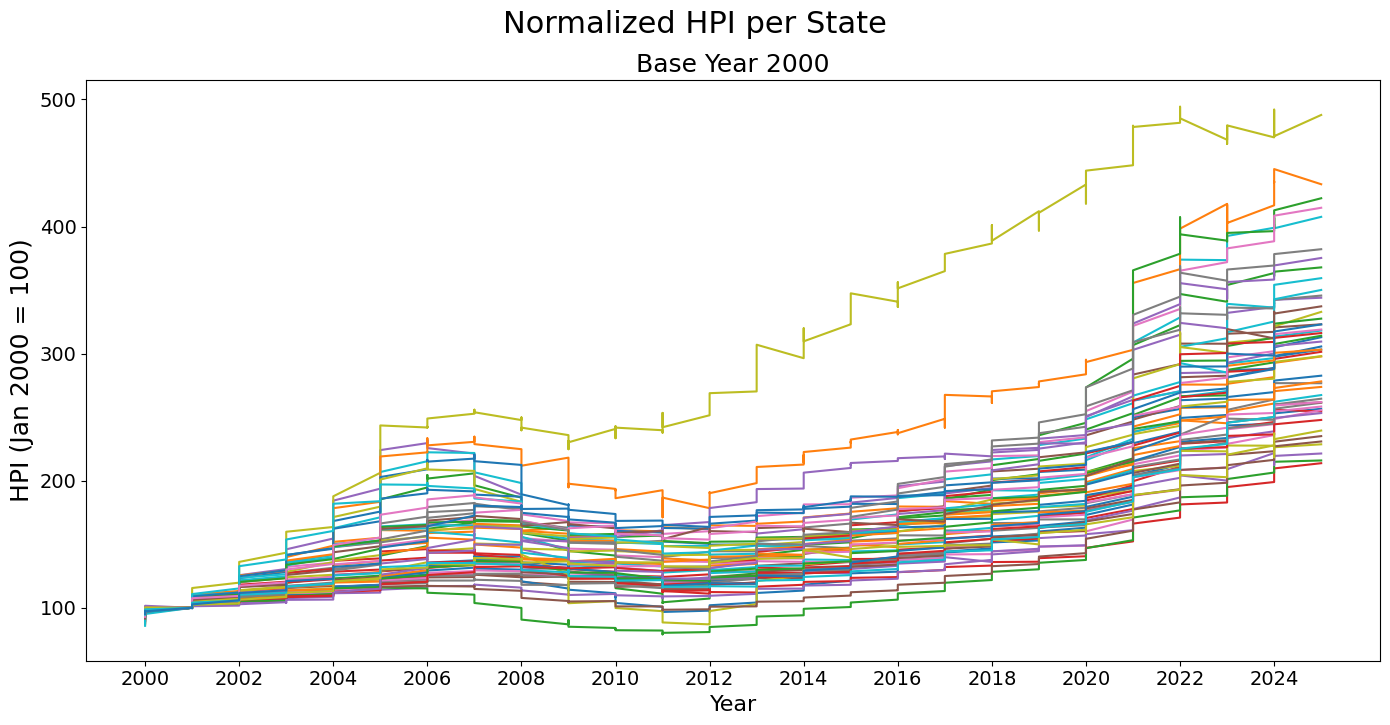

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file (assuming the correct filename)
csv_file_path = 'MacroData/StateMacros.csv'  # Replace this with your actual CSV file path

# Example dataframe loading:
df = pd.read_csv(csv_file_path)

# Rename columns for easier access
df.columns = ['State', 'YearMonth', 'UnemploymentRate', 'HPI']

# Filter from 2000 onwards
df = df[(df['YearMonth'] >= 200001)]

# Keep only January, April, July, and October months
df['Month'] = df['YearMonth'] % 100
df = df[df['Month'].isin([1, 4, 7, 10])]

# Create a dictionary to store normalization factors (HPI in January 2001)
norm_factors = {}

# Find January 2001 index for each state
states = df['State'].unique()
for state in states:
    jan_2001_hpi = df[(df['State'] == state) & (df['YearMonth'] == 200101)]['HPI']
    if not jan_2001_hpi.empty:
        norm_factors[state] = jan_2001_hpi.values[0]

# Normalize HPIs
def normalize(row):
    state = row['State']
    if state in norm_factors:
        return (row['HPI'] / norm_factors[state]) * 100
    else:
        return None  # Ignore states without January 2001 data

# Apply normalization
df['Normalized_HPI'] = df.apply(normalize, axis=1)

# Extract year for plotting
df['Year'] = df['YearMonth'] // 100

# Plotting
fig, ax = plt.subplots(figsize=(14, 8))
for state in states:
    state_df = df[df['State'] == state]
    if state_df['Normalized_HPI'].notnull().any():
        ax.plot(state_df['Year'], state_df['Normalized_HPI'], label=state)

fig.suptitle('Normalized HPI per State', fontsize=22, y=0.93)

ax.set_title('Base Year 2000', fontsize=18)

ax.set_xlabel('Year', fontsize=16)
ax.set_ylabel('HPI (Jan 2000 = 100)', fontsize=18)

# Customize x-ticks to show fewer years
years_to_show = list(range(2000, 2026, 2))  # Show every 2 years
ax.set_xticks(years_to_show)
ax.set_xticklabels(years_to_show, fontsize=14)

ax.tick_params(axis='y', labelsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Save the plot
plt.savefig('Charts/StateHPIChart.png', dpi=300)

plt.show()